AAPL — Train:1762 Val:124 Test:622


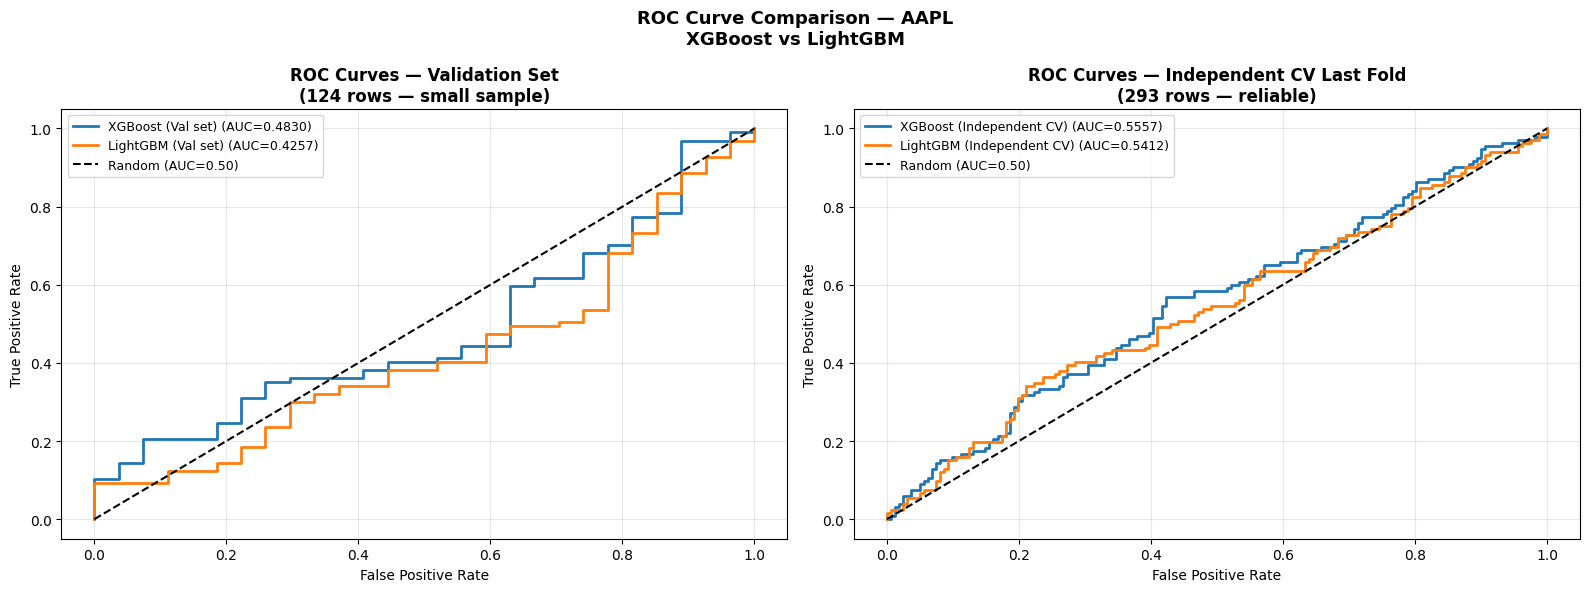

Val Set AUCs (124 rows — unreliable):
  XGBoost:  0.4830
  LightGBM: 0.4257

Independent CV AUCs (293 rows — reliable):
  XGBoost:  0.5557
  LightGBM: 0.5412


In [1]:
import sys, warnings
import numpy as np
import matplotlib.pyplot as plt
import joblib
import pandas as pd
warnings.filterwarnings('ignore')
sys.path.append('../..')
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import lightgbm as lgb
from src.models.data_loader import load_splits

# Load AAPL splits
X_tr, y_tr, X_v, y_v, X_te, y_te = load_splits('AAPL')

# Load saved models
xgb_model  = joblib.load('experiments/models/xgboost_AAPL.pkl')
lgbm_model = joblib.load('experiments/models/lgbm_AAPL.pkl')

# ── Get probabilities from direct validation set ─────────────
xgb_proba_val  = xgb_model.predict_proba(X_v)[:, 1]
lgbm_proba_val = lgbm_model.predict_proba(X_v)[:, 1]

# ── Get probabilities from independent CV (last fold only) ───
# We use the last fold of TimeSeriesSplit as it is most recent
# and most representative of real trading conditions
tscv = TimeSeriesSplit(n_splits=5)
folds = list(tscv.split(X_tr))
last_tr_idx, last_val_idx = folds[-1]

X_last_tr = X_tr.iloc[last_tr_idx]
y_last_tr = y_tr.iloc[last_tr_idx]
X_last_v  = X_tr.iloc[last_val_idx]
y_last_v  = y_tr.iloc[last_val_idx]

# XGBoost independent — retrain on last fold
xgb_params = xgb_model.get_params()
for k in ['scale_pos_weight','random_state','eval_metric',
          'verbosity','base_score','booster','callbacks',
          'early_stopping_rounds','enable_categorical',
          'feature_types','gamma','grow_policy',
          'interaction_constraints','max_bin','max_cat_threshold',
          'max_cat_to_onehot','max_delta_step','max_leaves',
          'missing','monotone_constraints','n_jobs',
          'num_parallel_tree','objective','sampling_method',
          'tree_method','validate_parameters','device']:
    xgb_params.pop(k, None)

xgb_ind = xgb.XGBClassifier(
    **xgb_params,
    scale_pos_weight=float((y_last_tr==0).sum()/(y_last_tr==1).sum()),
    eval_metric='auc', random_state=42, verbosity=0
)
xgb_ind.fit(X_last_tr, y_last_tr, verbose=False)
xgb_proba_ind = xgb_ind.predict_proba(X_last_v)[:, 1]

# LightGBM independent — retrain on last fold
lgbm_params = lgbm_model.get_params()
for k in ['verbose','scale_pos_weight','class_weight','n_jobs',
          'random_state','importance_type','subsample_for_bin',
          'min_split_gain','min_child_weight','objective']:
    lgbm_params.pop(k, None)

lgbm_ind = lgb.LGBMClassifier(
    **lgbm_params,
    scale_pos_weight=float((y_last_tr==0).sum()/(y_last_tr==1).sum()),
    random_state=42, verbose=-1
)
lgbm_ind.fit(X_last_tr, y_last_tr)
lgbm_proba_ind = lgbm_ind.predict_proba(X_last_v)[:, 1]

# ── Plot all 4 ROC curves ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left chart — Val set (124 rows)
for name, proba in [
    ('XGBoost (Val set)',  xgb_proba_val),
    ('LightGBM (Val set)', lgbm_proba_val)
]:
    fpr, tpr, _ = roc_curve(y_v, proba)
    auc = roc_auc_score(y_v, proba)
    axes[0].plot(fpr, tpr, linewidth=2,
                 label=f'{name} (AUC={auc:.4f})')

axes[0].plot([0,1],[0,1],'k--', label='Random (AUC=0.50)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Validation Set\n(124 rows — small sample)',
                   fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right chart — Independent CV last fold (293 rows)
for name, proba, y_true in [
    ('XGBoost (Independent CV)',  xgb_proba_ind,  y_last_v),
    ('LightGBM (Independent CV)', lgbm_proba_ind, y_last_v)
]:
    fpr, tpr, _ = roc_curve(y_true, proba)
    auc = roc_auc_score(y_true, proba)
    axes[1].plot(fpr, tpr, linewidth=2,
                 label=f'{name} (AUC={auc:.4f})')

axes[1].plot([0,1],[0,1],'k--', label='Random (AUC=0.50)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — Independent CV Last Fold\n(293 rows — reliable)',
                   fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('ROC Curve Comparison — AAPL\nXGBoost vs LightGBM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../docs/roc_curves.png', dpi=150)
plt.show()

# Summary
print('Val Set AUCs (124 rows — unreliable):')
print(f'  XGBoost:  {roc_auc_score(y_v, xgb_proba_val):.4f}')
print(f'  LightGBM: {roc_auc_score(y_v, lgbm_proba_val):.4f}')
print(f'\nIndependent CV AUCs (293 rows — reliable):')
print(f'  XGBoost:  {roc_auc_score(y_last_v, xgb_proba_ind):.4f}')
print(f'  LightGBM: {roc_auc_score(y_last_v, lgbm_proba_ind):.4f}')

AAPL — Train:1762 Val:124 Test:622
All 4 models ready!

Model Performance by Market Regime — All 4 Models:
       Regime  XGB Val  XGB Ind CV  LGBM Val  LGBM Ind CV  Samples  Up_Rate_%
 Low Vol Bull   0.8901      0.8737    0.8275       0.8470     1701      59.14
High Vol Bull   0.9758      0.9533    0.9710       0.9326      214      61.68
 Low Vol Bear   0.9103      0.8455    0.8862       0.8831      446      56.73
High Vol Bear   0.9690      0.6649    0.9901       0.6901      147      54.42

Best model per regime (Independent CV):
--------------------------------------------------
  Low Vol Bull         → XGB Val (0.8901) | 1701 samples | 59.14% up days
  High Vol Bull        → XGB Val (0.9758) | 214 samples | 61.68% up days
  Low Vol Bear         → XGB Val (0.9103) | 446 samples | 56.73% up days
  High Vol Bear        → LGBM Val (0.9901) | 147 samples | 54.42% up days


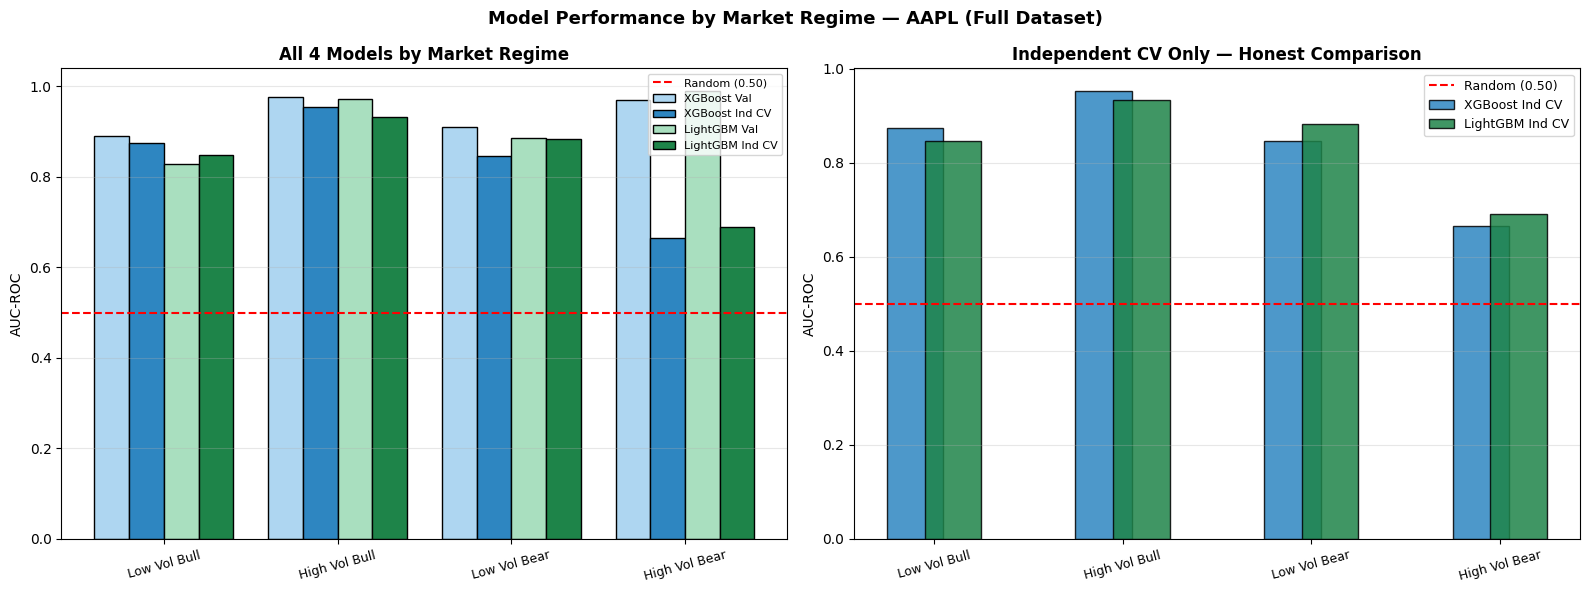

Chart saved!


In [3]:
import sys, warnings
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
sys.path.append('../..')
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from src.utils.config import PROCESSED_DIR
from src.models.data_loader import load_splits

# Load data
X_tr, y_tr, X_v, y_v, X_te, y_te = load_splits('AAPL')

# ── Use FULL dataset for regime analysis ─────────────────────
# Combine train + val + test for maximum coverage
X_full = pd.concat([X_tr, X_v, X_te])
y_full = pd.concat([y_tr, y_v, y_te])

aapl_full = pd.read_csv(PROCESSED_DIR / 'features/AAPL_features.csv',
                         index_col=0, parse_dates=True)
macro     = pd.read_csv(PROCESSED_DIR / 'features/macro_clean.csv',
                         index_col=0, parse_dates=True)

# Load saved models
xgb_model  = joblib.load('experiments/models/xgboost_AAPL.pkl')
lgbm_model = joblib.load('experiments/models/lgbm_AAPL.pkl')

# Build independent CV models from last fold
tscv  = TimeSeriesSplit(n_splits=5)
folds = list(tscv.split(X_tr))
last_tr_idx, _ = folds[-1]

X_last_tr = X_tr.iloc[last_tr_idx]
y_last_tr = y_tr.iloc[last_tr_idx]

# XGBoost independent
xgb_params = xgb_model.get_params()
for k in ['scale_pos_weight','random_state','eval_metric',
          'verbosity','base_score','booster','callbacks',
          'early_stopping_rounds','enable_categorical',
          'feature_types','gamma','grow_policy',
          'interaction_constraints','max_bin','max_cat_threshold',
          'max_cat_to_onehot','max_delta_step','max_leaves',
          'missing','monotone_constraints','n_jobs',
          'num_parallel_tree','objective','sampling_method',
          'tree_method','validate_parameters','device']:
    xgb_params.pop(k, None)

xgb_ind = xgb.XGBClassifier(
    **xgb_params,
    scale_pos_weight=float((y_last_tr==0).sum()/(y_last_tr==1).sum()),
    eval_metric='auc', random_state=42, verbosity=0
)
xgb_ind.fit(X_last_tr, y_last_tr, verbose=False)

# LightGBM independent
lgbm_params = lgbm_model.get_params()
for k in ['verbose','scale_pos_weight','class_weight','n_jobs',
          'random_state','importance_type','subsample_for_bin',
          'min_split_gain','min_child_weight','objective']:
    lgbm_params.pop(k, None)

lgbm_ind = lgb.LGBMClassifier(
    **lgbm_params,
    scale_pos_weight=float((y_last_tr==0).sum()/(y_last_tr==1).sum()),
    random_state=42, verbose=-1
)
lgbm_ind.fit(X_last_tr, y_last_tr)
print('All 4 models ready!')

# ── Classify regimes ─────────────────────────────────────────
def classify_regime(price_vs_sma200, vix):
    if   vix <= 25 and price_vs_sma200 >  0: return 'Low Vol Bull'
    elif vix >  25 and price_vs_sma200 >  0: return 'High Vol Bull'
    elif vix <= 25 and price_vs_sma200 <= 0: return 'Low Vol Bear'
    else:                                     return 'High Vol Bear'

# Align full dataset with regime data
full_dates   = X_full.index
full_feature = aapl_full.loc[aapl_full.index.isin(full_dates)]
macro_full   = macro.loc[macro.index.isin(full_dates)]
common_idx   = full_feature.index.intersection(macro_full.index)
full_feature = full_feature.loc[common_idx]
macro_full   = macro_full.loc[common_idx]

regimes = [
    classify_regime(row['Price_vs_SMA200'], macro_full.loc[date, 'vix'])
    for date, row in full_feature.iterrows()
    if date in macro_full.index
]

# Get predictions on full dataset
X_common = X_full.loc[common_idx]
y_common = y_full.loc[common_idx]

xgb_proba_val  = xgb_model.predict_proba(X_common)[:, 1]
lgbm_proba_val = lgbm_model.predict_proba(X_common)[:, 1]
xgb_proba_ind  = xgb_ind.predict_proba(X_common)[:, 1]
lgbm_proba_ind = lgbm_ind.predict_proba(X_common)[:, 1]

# AUC by regime
results = []
for regime in ['Low Vol Bull','High Vol Bull','Low Vol Bear','High Vol Bear']:
    mask = [r == regime for r in regimes]
    if sum(mask) < 10:
        continue

    y_r        = y_common.values[mask]
    p_xgb_val  = xgb_proba_val[mask]
    p_lgbm_val = lgbm_proba_val[mask]
    p_xgb_ind  = xgb_proba_ind[mask]
    p_lgbm_ind = lgbm_proba_ind[mask]

    if len(np.unique(y_r)) < 2:
        continue

    results.append({
        'Regime':         regime,
        'XGB Val':        round(roc_auc_score(y_r, p_xgb_val),  4),
        'XGB Ind CV':     round(roc_auc_score(y_r, p_xgb_ind),  4),
        'LGBM Val':       round(roc_auc_score(y_r, p_lgbm_val), 4),
        'LGBM Ind CV':    round(roc_auc_score(y_r, p_lgbm_ind), 4),
        'Samples':        sum(mask),
        'Up_Rate_%':      round(y_r.mean() * 100, 2)
    })

regime_df = pd.DataFrame(results)

print('\nModel Performance by Market Regime — All 4 Models:')
print('=' * 70)
print(regime_df.to_string(index=False))

print('\nBest model per regime (Independent CV):')
print('-' * 50)
for _, row in regime_df.iterrows():
    scores = {
        'XGB Val':     row['XGB Val'],
        'XGB Ind CV':  row['XGB Ind CV'],
        'LGBM Val':    row['LGBM Val'],
        'LGBM Ind CV': row['LGBM Ind CV'],
    }
    best = max(scores, key=scores.get)
    print(f"  {row['Regime']:<20} → {best} ({scores[best]:.4f}) "
          f"| {row['Samples']} samples | {row['Up_Rate_%']}% up days")

# ── Visualization ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x     = range(len(regime_df))
width = 0.2

# Left — all 4 models
axes[0].bar([i-1.5*width for i in x], regime_df['XGB Val'],
            width, label='XGBoost Val',
            color='#AED6F1', edgecolor='black')
axes[0].bar([i-0.5*width for i in x], regime_df['XGB Ind CV'],
            width, label='XGBoost Ind CV',
            color='#2E86C1', edgecolor='black')
axes[0].bar([i+0.5*width for i in x], regime_df['LGBM Val'],
            width, label='LightGBM Val',
            color='#A9DFBF', edgecolor='black')
axes[0].bar([i+1.5*width for i in x], regime_df['LGBM Ind CV'],
            width, label='LightGBM Ind CV',
            color='#1E8449', edgecolor='black')

axes[0].axhline(0.5, color='red', linestyle='--',
                linewidth=1.5, label='Random (0.50)')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(regime_df['Regime'], rotation=15, fontsize=9)
axes[0].set_title('All 4 Models by Market Regime',
                   fontweight='bold')
axes[0].set_ylabel('AUC-ROC')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

# Right — independent CV only
axes[1].bar([i-0.5*width for i in x], regime_df['XGB Ind CV'],
            width*1.5, label='XGBoost Ind CV',
            color='#2E86C1', edgecolor='black', alpha=0.85)
axes[1].bar([i+0.5*width for i in x], regime_df['LGBM Ind CV'],
            width*1.5, label='LightGBM Ind CV',
            color='#1E8449', edgecolor='black', alpha=0.85)

axes[1].axhline(0.5, color='red', linestyle='--',
                linewidth=1.5, label='Random (0.50)')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(regime_df['Regime'], rotation=15, fontsize=9)
axes[1].set_title('Independent CV Only — Honest Comparison',
                   fontweight='bold')
axes[1].set_ylabel('AUC-ROC')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Model Performance by Market Regime — AAPL (Full Dataset)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../docs/regime_performance.png', dpi=150)
plt.show()
print('Chart saved!')